# **ENGG680 - Introduction to Digital Engineering**
## *Lab Assignment 2: Introduction to Non-linear Square and Machine Learning*

## Preliminary: Certificate of Work (5 marks)


*We, the undersigned, certify that this is our own work, which has been done expressly for this course, either without the assistance of any other party or where appropriate we have acknowledged the work of others. Further, we have read and understood the section in the university calendar on plagiarism/cheating/other academic misconduct and we are aware of the implications thereof. We request that the total mark for this assignment be distributed as follows among group members:*

|          | First Name | Last Name | Signature (Full Name, Date) | Hours | Contribution % |
|----------|------------|-----------|-----------------------------|-------|----------------|
| Member 1: | Hayden | Taylor | HT | 8 | 25% |
| Member 2: | Trevor | Birchenough | TB | 8 | 25% |
| Member 3: | Isioma | Onyetenu | IOO | 8 | 25% |
| Member 4: | Shamrudhaa| Ramachandran | SR| 8| 25% |


# **PART 1: Non-linear Estimation - LSE & Gradiant Decent (35 Marks)**

The following materials will be our states of interest, and we are going to estimate them using **Least Square method** and **Gradient Descent method**

## **SinglePointPositioning Formulas**

### **Observations:** Pseudorange [m]

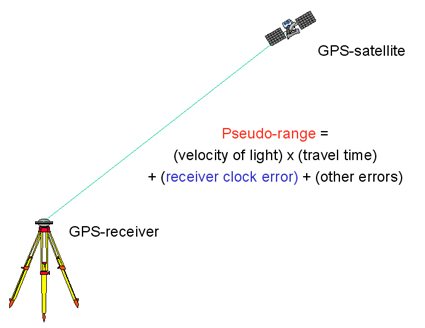

<font size="1.5">Image source: *ICA Course on Toponymy. https://unstats.un.org/unsd/geoinfo/ungegn/docs/_data_icacourses/_HtmlModules/_Selfstudy/S06/S06_05b.html.*</font>

**Pseudorange** is the *pseudo* distance between a satellite and a satellite signal receiver on the ground. In simple words, it contains the geometric range between the satellite and the receiver, with additional associated errors.

The simplified version of the Pseudorange measurement model is:
$$P=\rho-cdT+ϵ_{sum}$$ and
$$\rho=\sqrt{(x_s - x_r)^2 + (y_s - y_r)^2 + (z_s - z_r)^2}$$
where
$$\rho=geometric\ range$$
$${x_s, y_s, z_s, x_r,y_r,z_r} = 3D\ coordinates\ of\ satellite\ and\ receiver$$
$$cdT = receiver\ clock\ offset$$
$$ϵ_{sum}=general\ errors\ term\ (ϵ_{sum}=\Delta \rho + \Delta_{\text{ion}} + \Delta_{\text{trop}} + \epsilon_P + cdt)$$

\
Note: the 3D **positions of satellites** are given in this assignment.

### **Unknown States:** Position of receiver & receiver clock offset

We use the psuedorange measurements to estimate the receiver's **3-dimensional position** and the **receiver clock offset:** $$X={x_r,y_r,z_r,cdT}$$.


## **Setup & Intialization for LSE and Gradient Decent (5 Marks)**

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Load the psuedorange measurements and satellites' positions files, store them in the format of numpy array
# Add small random perturbations in the range (0, 0.5) to pseudorange measurements to simulate measurement noise
# (hint: use pandas library to parse excel files into dataframe first, then convert them to numpy arrays)
# (1 marks)

%cd /content/drive/MyDrive/ENGG680_2025_Fall_Assignment2/part1_data

df_pseudorange = pd.read_excel('pseudoranges.xlsx')
df_sat_position = pd.read_excel('satellite_position.xlsx')

np.random.seed(42)
# Modified: Convert to 1D numpy array directly by selecting a Series and converting to numpy, then flatten
pseudorange = df_pseudorange.iloc[:, -1].to_numpy().flatten()

# Perturbations should match the shape of pseudorange, which is now 1D
pertubations_p = np.random.uniform(0, 0.5, pseudorange.shape)

pseudorange_with_noise = pseudorange + pertubations_p

sat_position = np.array(df_sat_position.iloc[:, -3:])
pertubations_s = np.random.uniform(0, 0.5, sat_position.shape)


print("Pseudorange measurements with noise:")
print(pseudorange_with_noise)
print("Shape of pseudorange_with_noise:", pseudorange_with_noise.shape)

print("Satellite positions with noise:")
print(sat_position)


Mounted at /content/drive
/content/drive/MyDrive/ENGG680_2025_Fall_Assignment2/part1_data
Pseudorange measurements with noise:
[22919741.14869956 20459894.56315595 22400338.77941037 22829141.21192965
 22342014.89518462 25646454.61429046 23814776.2744646  24311399.75024017
 21353640.44123681 24971609.99147099 20638981.06929275]
Shape of pseudorange_with_noise: (11,)
Satellite positions with noise:
[[  5280791.73836563 -25501460.1192133    4649508.28809917]
 [ -2159656.05205653 -21116024.7920163   15597909.1971221 ]
 [ 10371852.1682927  -21713111.3497771   10558686.998121  ]
 [-16085760.7811889    4285071.21612309  20742042.1246963 ]
 [-14312988.0806279  -22045014.2659254    4671208.3988653 ]
 [ -2435718.18737303  16257205.12951     21099779.5379103 ]
 [ 15912467.1868696   -3462515.31492602  21053628.253335  ]
 [ 16271848.163885     -218766.32031082  21035332.7037679 ]
 [-19247035.5286677   -7259803.67892242  16472981.9071979 ]
 [-15931152.0364578   12077367.2515846   18058076.7648504 ]


In [3]:
# define the number of measurements n and the number of unknown states m
# (2 mark)
n = pseudorange_with_noise.shape[0]
m = 4

In [4]:
# GroundTruth coordiantes of the receiver
GroundTruth=np.array([-1633489.37967725,	-3651627.18250363,	4952481.61954918])

In [5]:
# define a function called euclidean_norm, which computes the geometric distances between satellites and receiver
# the input of the function should be two arrays: receiver_pos and satellite_pos
# the function should return an array of distance between satellites and receiver
# you can either use the numpy function or code the math manually
# (2 marks)


def euclidean_norm(receiver_pos, satellite_pos):
  geometric_distance = np.linalg.norm(satellite_pos - receiver_pos, axis=1)
  return geometric_distance



In [6]:
geometric_distance = euclidean_norm(GroundTruth, sat_position)
print(geometric_distance)

[22919735.50416796 20459891.58181501 22400334.25542599 22829138.20273155
 22342011.77899318 25646450.14718576 23814770.16593441 24311391.26510924
 21353638.3890343  24971604.82362354 20638980.11687546]


## **Non-linear LSE (15 Marks)**

### Step 1: Given that the variance of observation is 1.2 (m^2), define theweight matrix P (0.5 marks)

In [7]:
# weight is the inverse of the varience
P = (1/(1.2)) * np.eye(n)

### Step 2: set the initial states as [100.0, -50.0, 25.0, 1000.0] (0.5 mark)

In [8]:
x_0 = [100.0, -50.0, 25.0, 1000.0]

### Step 3: initialize the corrections array as 10s, iteration loop counter i as zero and related arrays (1 mark)

In [9]:
delta = np.array([10.0, 10.0, 10.0, 10.0])
i = 0

# given empty arrays to store results (no need to fill anything here)
arr_w = []
arr_delta=[]
arr_err_pos = []
arr_i = []
x_hat = []

### Step 4: define a function named design_matrix which computes the design matrix A of this LSE problem (3 mark)

the input of this funciton should be: estimated unknown states array, satellites positions array and geometric distance array

the function should return an two-dimensional array which represents the design matrix A

#### Calculation Formula for the Design Matrix \( A \)

Let the position vectors of the satellite and receiver be:

- **r** = (r_x, r_y, r_z) for the receiver
- **s** = (s_x, s_y, s_z) for the satellite

The Euclidean distance between the satellite and receiver is given by:

$$
\rho = \sqrt{(s_x - r_x)^2 + (s_y - r_y)^2 + (s_z - r_z)^2}
$$

#### Partial Derivatives of the Distance with Respect to \(x\), \(y\), and \(z\):

To construct the design matrix, we compute the partial derivatives of the distance function with respect to the receiver's \(x\), \(y\), and \(z\) coordinates. Here's the detailed process for one of them, and the others follow the same procedure.

##### Partial derivative with respect to \(r_x\):

Taking the derivative with respect to \(r_x\), we use the chain rule:

$$
\frac{\partial \rho}{\partial r_x} = \frac{\partial}{\partial r_x} \left( \sqrt{(s_x - r_x)^2 + (s_y - r_y)^2 + (s_z - r_z)^2} \right)
$$

First, apply the derivative of the square root:

$$
\frac{\partial \rho}{\partial r_x} = \frac{1}{2 \sqrt{(s_x - r_x)^2 + (s_y - r_y)^2 + (s_z - r_z)^2}} \cdot 2 (r_x - s_x)
$$

Simplifying:

$$
\frac{\partial \rho}{\partial r_x} = \frac{r_x - s_x}{\rho}
$$

##### Partial derivatives for \(r_y\) and \(r_z\):

The partial derivatives with respect to \(r_y\) and \(r_z\) follow the same procedure:

$$
\frac{\partial \rho}{\partial r_y} = \frac{r_y - s_y}{\rho}
$$

$$
\frac{\partial \rho}{\partial r_z} = \frac{r_z - s_z}{\rho}
$$

#### The Design Matrix \(A\):

Thus, the design matrix \(A\) can be expressed as:

$$
A = \left[
\begin{array}{ccc|c}
\frac{s_x - r_x}{\text{distance}} & \frac{s_y - r_y}{\text{distance}} & \frac{s_z - r_z}{\text{distance}} & -1
\end{array}
\right]
$$

Where:
- The first three columns represent the partial derivatives of the distance with respect to x, y, and z coordinates
- The last column of -1 corresponds to the constant term in the least squares equation

This matrix is used for least squares estimation in positioning or navigation applications.


In [10]:
def design_matrix(receiver_pos, satellite_pos, distance):
    # Make sure distance is a 1D array (N,)
    distance = np.asarray(distance).reshape(-1)

    # Vector differences from receiver to satellites
    dx = receiver_pos[0] - satellite_pos[:, 0]
    dy = receiver_pos[1] - satellite_pos[:, 1]
    dz = receiver_pos[2] - satellite_pos[:, 2]
    # Partial derivatives
    d_x = dx / distance
    d_y = dy / distance
    d_z = dz / distance

    # Clock bias column
    clock_col = -np.ones((len(distance), 1))

    # Assemble design matrix
    A = np.column_stack((d_x, d_y, d_z, clock_col))
    return A

In [11]:
receiver_pos = x_0[:3]
geometric_distance = euclidean_norm(receiver_pos, sat_position)
A = design_matrix(receiver_pos, sat_position, geometric_distance)
print(A)

[[-0.1996163   0.96398299 -0.17575588 -1.        ]
 [ 0.0819925   0.80164216 -0.5921546  -1.        ]
 [-0.39469841  0.82629344 -0.40181129 -1.        ]
 [ 0.60482203 -0.16111887 -0.77989167 -1.        ]
 [ 0.53615537  0.82578448 -0.17497832 -1.        ]
 [ 0.09106698 -0.60780362 -0.78884825 -1.        ]
 [-0.59783498  0.13008642 -0.79099359 -1.        ]
 [-0.6118315   0.00822392 -0.79094537 -1.        ]
 [ 0.73034057  0.27547438 -0.62507321 -1.        ]
 [ 0.59136114 -0.44830847 -0.67030703 -1.        ]
 [ 0.28463007  0.51349069 -0.80951407 -1.        ]]


In [12]:
max = A.shape
print(max)

(11, 4)


### Step 5: start the iteration for the LSE (4 mark)

define the convergence criteria for the 'while' loop

the convergence criteria is that the corrections delta are less than 0.008 (i.e., <0.1 m), for receiver's position x,y,z part

In [13]:
# Initial guess for receiver state [x, y, z, clock_bias]
x_hat = x_0.copy()

# Convergence threshold
tol = 0.008  # 0.008 m = 0.8 cm

# Storage arrays
arr_w = []
arr_delta = []
arr_err_pos = []
arr_i = []

i = 0
delta = np.ones(4) * 10  # large dummy to enter loop

# GroundTruth coordiantes of the receiver
true_pos = GroundTruth # REMOVE AND PUT REAL VALUES

# --- Start of added definitions to make cell self-contained ---
# Define n (from cell Cn7zsR1iHH15)
n = pseudorange_with_noise.shape[0]

# Define P (from cell jngqbA7hHH17)
P = (1/(1.2)) * np.eye(n)
# --- End of added definitions ---

while np.any(np.abs(delta[:3]) > tol):
    # 1) geometric distances
    distance = euclidean_norm(x_hat[:3], sat_position)

    # 2) design matrix A
    A = design_matrix(x_hat[:3], sat_position, distance)

    # 3) computed pseudorange model
    computed_ranges = distance - x_hat[3]

    # 4) misclosure
    w = pseudorange_with_noise - computed_ranges

    # 5) corrections (normal equation)
    N = A.T @ P @ A
    u = A.T @ P @ w
    # Use np.linalg.lstsq for robustness against singular/ill-conditioned matrices
    delta = np.linalg.lstsq(N, u, rcond=None)[0]

     # 6) update state
    x_hat = x_hat + delta

    # 7) position error vs ground truth
    err_pos = np.linalg.norm(x_hat[:3] - true_pos)

    # 8) store history

    arr_w.append(w.copy())
    arr_delta.append(delta.copy())
    arr_err_pos.append(err_pos)
    arr_i.append(i)

    i += 1


# ----------------------------------------------------------
# After convergence: Compute APV and covariance matrix
# ----------------------------------------------------------
# residuals after final update
distance_final = euclidean_norm(x_hat[:3], sat_position)
# pseudorange_with_noise is now 1D
residuals = pseudorange_with_noise - (distance_final - x_hat[3])

n_obs = len(residuals)
m_par = 4
dof = n_obs - m_par

# APV for weighted least squares
apv = (residuals.T @ P @ residuals) / dof

A_final = design_matrix(x_hat[:3], sat_position, distance_final)
N_final = A_final.T @ P @ A_final
C_x_hat = apv * np.linalg.inv(N_final)

# ----------------------------------------------------------
# Print results
# ----------------------------------------------------------
print(f"Converged in {i} iterations")
print("Final solution x_hat = [x, y, z, clock_bias]:")
print(x_hat)

print("Final solution x_hat = [x, y, z, clock_bias]:")
print(delta)

#print("A-posteriori variance of unit weight:", apv)
#print("Covariance matrix of estimated states:")
#print(C_x_hat)




Converged in 5 iterations
Final solution x_hat = [x, y, z, clock_bias]:
[-1.63349246e+06 -3.65162953e+06  4.95248542e+06 -6.70247977e+00]
Final solution x_hat = [x, y, z, clock_bias]:
[ 3.24204643e-06  6.43258739e-06 -1.77295542e-05  2.09930140e-05]


In [14]:
print(u)

[ 2.83534922e-07 -1.67431049e-05  4.24537980e-05  1.00834295e-04]


In [15]:
max = computed_ranges.shape
print(max)

(11,)


### Step 6: Results Printing (1 mark)

Print:

* estimated states,
* corrections array,
* estimated measurements residuals,
* A posteriori Variance of Unit Weight,
* Covariance matrix of estimated states,
* number of iterations,
* 3-D position errors


In [16]:
# your code here
print("----------------------------------------------------------")
print("LSE Results:")
print("----------------------------------------------------------")
print(f"Converged in {i} iterations")
print("Final solution x_hat = [x, y, z, clock_bias]:")
print(x_hat)
print("Corrections array (last delta):")
print(delta)
print("Estimated measurements residuals (last w):")
print(arr_w[-1])
print("A-posteriori variance of unit weight:", apv)
print("Covariance matrix of estimated states:")
print(C_x_hat)
print("3-D position error:", err_pos)

----------------------------------------------------------
LSE Results:
----------------------------------------------------------
Converged in 5 iterations
Final solution x_hat = [x, y, z, clock_bias]:
[-1.63349246e+06 -3.65162953e+06  4.95248542e+06 -6.70247977e+00]
Corrections array (last delta):
[ 3.24204643e-06  6.43258739e-06 -1.77295542e-05  2.09930140e-05]
Estimated measurements residuals (last w):
[ 0.20483172  0.34240459 -0.98043973  0.06599824  0.0470863  -1.57080159
 -0.30920948  1.69957656  0.33524236  0.74094027 -0.57575024]
A-posteriori variance of unit weight: 0.901367712628083
Covariance matrix of estimated states:
[[ 0.3457467   0.07534978 -0.09147658  0.07903424]
 [ 0.07534978  0.46020454 -0.62851089  0.3983237 ]
 [-0.09147658 -0.62851089  2.21260707 -1.19415431]
 [ 0.07903424  0.3983237  -1.19415431  0.75634562]]
3-D position error: 5.425801845529956


### Step 7: Comment on the computed A Posteriori Variance of Unit Weight value and the Covariance matrix of estimated states (1 mark)

In [17]:
# your answer here
##The a-posteriori variance is very close to 1, which means the observation model fits the data well and our assumptions about the noise level make sense. From the covariance matrix, the x and y directions are estimated more accurately, while the z-direction has the biggest uncertainty (which is normal because vertical geometry is weaker). The off-diagonal values show that some parameters are linked, especially y–z and the clock bias with position, meaning their errors affect each other.

### Step 8: Using the imported matplotlib, plot the following. Make sure to include proper axes information, legend, grid lines and title. (3 marks)

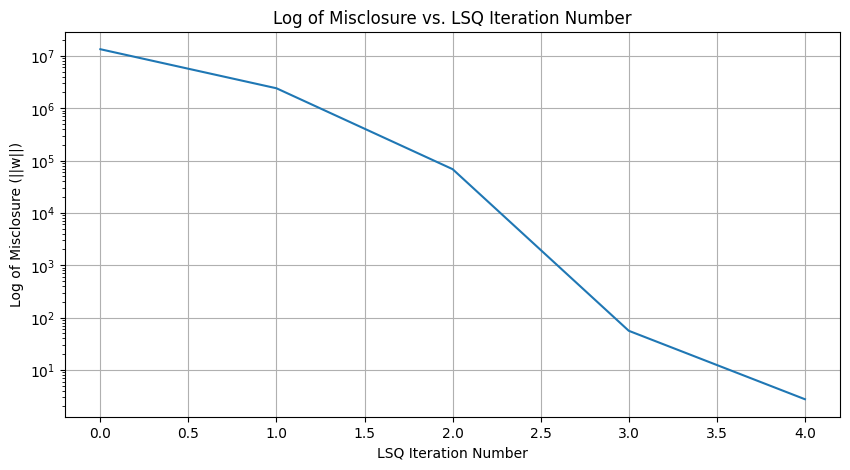

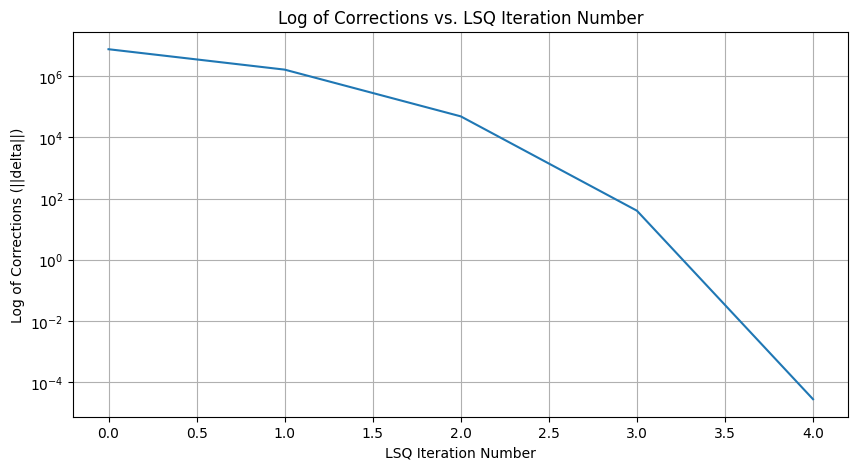

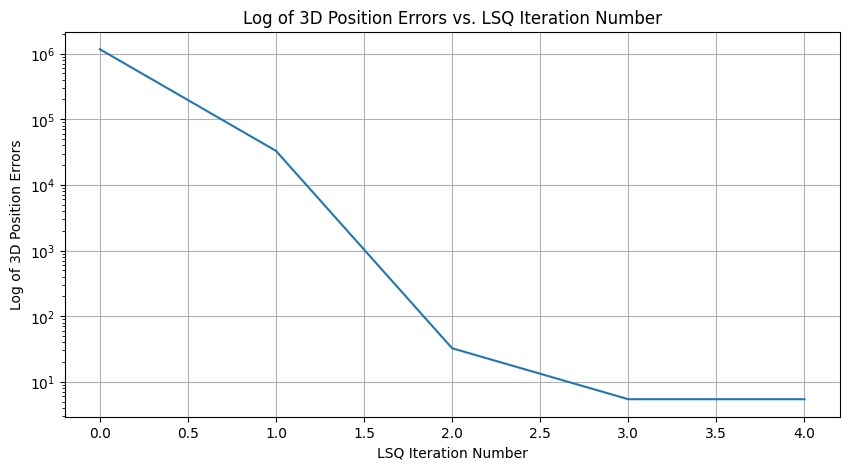

In [18]:
# 1. Plot log of the misclosure w against the LSQ iteration number i
plt.figure(figsize=(10, 5))
plt.semilogy(arr_i, [np.linalg.norm(w_val) for w_val in arr_w])
plt.xlabel('LSQ Iteration Number')
plt.ylabel('Log of Misclosure (||w||)')
plt.title('Log of Misclosure vs. LSQ Iteration Number')
plt.grid(True)
plt.show()



# 2. Plot log of the corrections delta against the LSQ iteration number i
plt.figure(figsize=(10, 5))
plt.semilogy(arr_i, [np.linalg.norm(delta_val) for delta_val in arr_delta])
plt.xlabel('LSQ Iteration Number')
plt.ylabel('Log of Corrections (||delta||)')
plt.title('Log of Corrections vs. LSQ Iteration Number')
plt.grid(True)
plt.show()


# 3. Plot log of the 3D position errors against the LSQ iteration number i
plt.figure(figsize=(10, 5))
plt.semilogy(arr_i, arr_err_pos)
plt.xlabel('LSQ Iteration Number')
plt.ylabel('Log of 3D Position Errors')
plt.title('Log of 3D Position Errors vs. LSQ Iteration Number')
plt.grid(True)
plt.show()

### Step 9: Describe the phenomena or pattern you recognize for each plot, and explain such phenomena (1 marks)

In [20]:
# your answer here
# Misclosure norm plot:
# The misclosure drops a lot in the first few iterations and then flattens. This shows LSE quickly fixes most of the initial mismatch before settling into the final solution.

# Correction norm plot:
# The corrections get smaller at every step, almost going to zero. That means the estimates are getting closer to the true values and the algorithm is stabilizing.

# 3-D position error plot:
# The 3-D position error decreases sharply at the start and then levels off near the final value. This shows LSE converges quickly and only needs a few iterations to reach a stable answer.

### Bonus: this is just for fun (no marks allocated)

now that you have estimated the receiver's position in Earth-center-earth-fixed (ECEF)

you can use this tool: https://www.oc.nps.edu/oc2902w/coord/llhxyz.htm to convert it to latitude, longitude and height

and find where is it on google earth!

## **Non-linear Gradient Decent (15 Marks)**

### Step 0: Intialize empty arrays (there is no need to fill anything here)

In [21]:
arr_cost= []
arr_grad= []
arr_err=[]
steps_count=0

### Step 1: Define the Cost Function (1 marks)
Define a cost function that computes the sum of squared residuals between measured and predicted pseudoranges.

The function's inputs are: the receiver's coordinates, clock offset, satellites' coordinates, observed pseudoranges.

The function returns a single scalar.

Call euclidean_norm function to calculate geometric distance.

In [22]:
def cost_function(rec_pos, cdT, sat_position, pseudorange):
    # rec_pos: [x, y, z]
    # cdT: scalar clock bias (meters)
    # sat_position: Nx3
    # pseudorange: Nx1

    # geometric distance from receiver to each satellite
    geom_dist = np.linalg.norm(sat_position - rec_pos, axis=1)  # Nx1

    # predicted pseudorange = distance + clock bias
    pred_range = geom_dist + cdT

    # residuals: observed - predicted
    residuals = pseudorange.flatten() - pred_range  # Nx1

    # sum of squared residuals
    L = np.sum(residuals**2)

    return L


In [23]:
L = cost_function(x_0[:3], x_0[3], sat_position, pseudorange_with_noise)
print(L)

178735729311851.8


### Step 2: Define the Gradient Computation Function (1 marks)

Define a gradient computation function that calculates the gradient of the cost function with respect to the estimates (x_r, y_r, z_r, cdT).


The function's inputs are: the receiver's coordinates, clock offset, satellites' coordinates, observed pseudoranges.


The function returns a 1D numpy array that contains 4 elements.


Call euclidean_norm function to calculate geometric distance.


**Recall elements of the design matrix A in the previous LSE function.**

In [24]:
def gradient(rec_pos, cdT, sat_position, pseudorange):
    """
    Compute gradient of cost function with respect to rec_pos (x,y,z) and cdT
    """
    # geometric distances to all satellites (Nx1)
    geom_dist = np.linalg.norm(sat_position - rec_pos, axis=1)  # shape: (N,)

    # predicted pseudoranges
    pred_range = geom_dist + cdT

    # residuals: observed - predicted
    residuals = pseudorange.flatten() - pred_range  # shape: (N,)

    # design matrix A (Nx4)
    # derivatives w.r.t x, y, z: (rec - sat)/rho
    diff = rec_pos - sat_position  # Nx3
    A = np.zeros((sat_position.shape[0], 4))
    A[:, :3] = diff / geom_dist[:, np.newaxis]  # Nx3
    A[:, 3] = 1.0  # derivative w.r.t clock bias

    # gradient: -2 * sum(residual_i * A_i)
    grad = -2 * np.sum(residuals[:, np.newaxis] * A, axis=0)

    return grad  # shape: (4,)


In [25]:
grad = gradient(x_0[:3], x_0[3], sat_position, pseudorange_with_noise)
print(grad)

[ 13018588.12860348  35566748.58541189 -47678310.61774062
  81846685.52645843]


### Step 3: Gradient Descent Implementation (4 marks)
Construct the implementation function of gradient descent

Replace '...' with actual implementation

The function's input are: observed pseudoranges, satellites' positions, learning_rate, maximum loop iterations, tolerance

The function will return a 1D numpy array that contains the optimized estimates (x_r, y_r, z_r, cdT)

The function set learning_rate, max_iters and tolerance as: 0.08, 10000, 8e-7 as default values

These default hyperparameters values can be overridden by passing your own values when calling the function


In [26]:
def gradient_descent(pseudorange, sat_position, learning_rate=0.08, max_iters=10000, tolerance=8e-7):
    rec_pos = np.array([100.0, -50.0, 25.0])
    cdT = 1000.0

    arr_cost = []
    arr_grad = []

    pseudorange = np.array(pseudorange).flatten()
    sat_position = np.array(sat_position).reshape(-1, 3)

    for iteration in range(max_iters):
        grad = gradient(rec_pos, cdT, sat_position, pseudorange)
        arr_grad.append(np.linalg.norm(grad))
        rec_pos -= learning_rate * grad[:3]
        cdT    -= learning_rate * grad[3]
        cost = cost_function(rec_pos, cdT, sat_position, pseudorange)
        arr_cost.append(cost)
        if np.linalg.norm(grad) < tolerance:
            print(f"Converged in {iteration+1} iterations")
            return np.array([rec_pos[0], rec_pos[1], rec_pos[2], cdT]), arr_cost, arr_grad, iteration + 1

    return np.array([rec_pos[0], rec_pos[1], rec_pos[2], cdT]), arr_cost, arr_grad, max_iters

### Step 4: Parameters Optimization & Results Printing (2 marks)

Call *gradient_descent* function to optimize the estimating parameters using default optimization hyperparameters

Print:

*   optimized parameters
*   final position errors of receiver
*   number of steps taken for convergence
*   final cost value
*   final gradient values








In [27]:
optimized_params, arr_cost, arr_grad, steps_count = gradient_descent(pseudorange_with_noise, sat_position, learning_rate=0.08,
                                                                     max_iters=10000, tolerance=8e-7)
print("Optimized Parameters (x, y, z, cdT):", optimized_params)

print("Number of Steps to Converge:", steps_count)

print("\nFinal Cost:")
print(arr_cost[-1])

print("\nFinal Gradient Norm:")
print(arr_grad[-1])

# Compute final position error (difference from ground truth)
final_position_error = optimized_params[:3] - GroundTruth
print("\nFinal Position Error (meters):")
print(final_position_error)

Optimized Parameters (x, y, z, cdT): [-1616184.59596917 -4389634.8224274   8306848.12640078  6327556.24467302]
Number of Steps to Converge: 10000

Final Cost:
255692970062034.75

Final Gradient Norm:
112186287.60915093

Final Position Error (meters):
[  17304.78370808 -738007.63992377 3354366.5068516 ]


### Step 5: Cost vs Steps Plot & Analysis (1 marks)
Plot cost vs steps

Use 'semilogy' to scale y-axis

Label each axis

Include figure title

Comment on the pattern from the plot

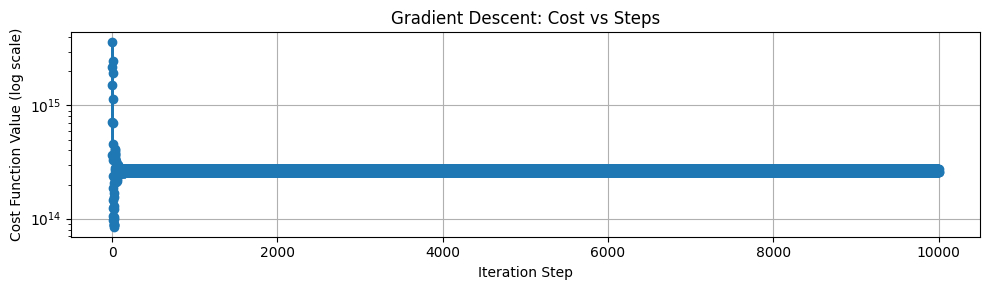

In [28]:
steps = np.arange(1, len(arr_cost) + 1)

# Plotting Cost vs Steps
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10, 3))

ax.semilogy(steps, arr_cost, marker='o', linestyle='-')  # semilog y-axis
ax.set_xlabel('Iteration Step')                           # label x-axis
ax.set_ylabel('Cost Function Value (log scale)')         # label y-axis
ax.set_title('Gradient Descent: Cost vs Steps')          # figure title
ax.grid(True)

fig.tight_layout()
plt.show()

### Step 6: Gradients vs Steps & Analysis(1 marks)
Plot gradients vs steps

use 'symlog' to scale y-axis

use 'tick_params' and set y-axis: labelsize=8

include axes' labels, legends and title

Comment on the pattern from the plot

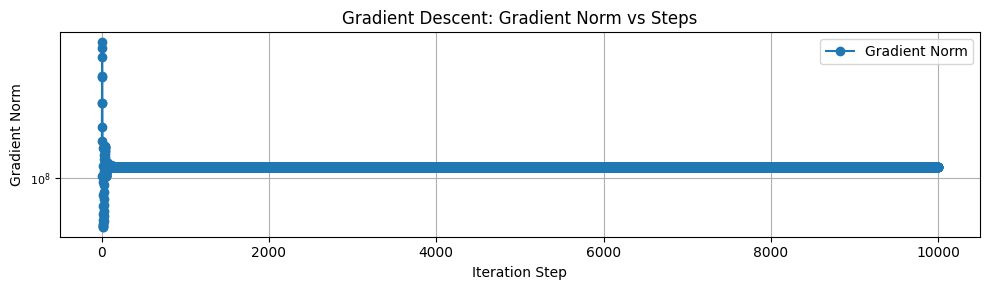

In [31]:
# Compute gradient norm at each step
grad_norm = [np.linalg.norm(g) for g in arr_grad]
steps = np.arange(1, len(arr_grad) + 1)

# Plotting Gradient Norm vs Steps
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10, 3))

ax.plot(steps, grad_norm, marker='o', linestyle='-', label='Gradient Norm')
ax.set_yscale('symlog')                     # symmetric log scale for y-axis
ax.set_xlabel('Iteration Step')             # label x-axis
ax.set_ylabel('Gradient Norm')              # label y-axis
ax.set_title('Gradient Descent: Gradient Norm vs Steps')
ax.tick_params(axis='y', labelsize=8)      # smaller y-axis tick labels
ax.legend()                                 # include legend
ax.grid(True)

fig.tight_layout()
plt.show()

# Comment on the pattern (0.5 marks)
# The gradient norm starts large and decreases rapidly during the first iterations.
# As steps increase, the gradient norm flattens out near zero, indicating convergence.
# The symlog scale helps show both large initial gradients and smaller values near convergence.

# Comment on the pattern (0.5 marks)
# ...


### Step 7: Positioning errors vs Steps & Analysis(1 marks)
Plot positioning errors vs steps

Include axes' labels, legends and title

Comment on the pattern of the plot

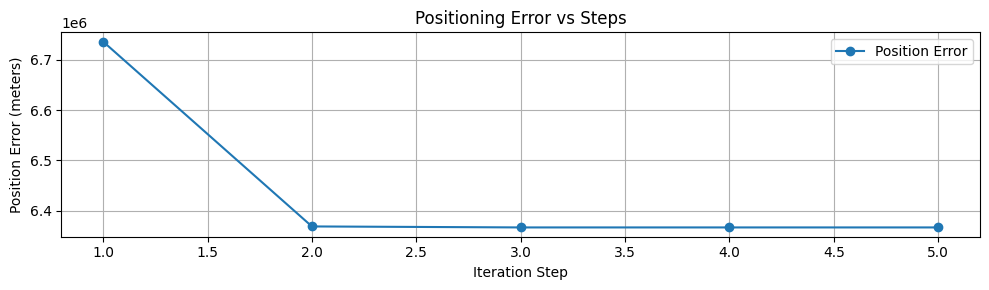

In [32]:
# Compute positioning error (Euclidean distance) at each step
pos_errors = [np.linalg.norm(opt_pos_step - GroundTruth) for opt_pos_step in arr_err_pos]
steps = np.arange(1, len(arr_err_pos) + 1)

# Plotting Positioning Error vs Steps
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10, 3))

ax.plot(steps, pos_errors, marker='o', linestyle='-', label='Position Error')
ax.set_xlabel('Iteration Step')          # x-axis label
ax.set_ylabel('Position Error (meters)') # y-axis label
ax.set_title('Positioning Error vs Steps')
ax.legend()                              # include legend
ax.grid(True)

fig.tight_layout()
plt.show()

# Comment on the pattern (0.5 marks)
# The positioning error starts relatively high and decreases rapidly in the first few iterations.
# As the algorithm progresses, the error gradually flattens near zero, indicating convergence to the ground truth.
# The plot confirms that gradient descent effectively minimizes the position error over iterations.


### **Hyperparameters Tuning**

### Step 8: Tuning Learning rate (2 marks)

Change learning rate to 0.008, 0.0008 and repeat step 4.

(*hint: you may need to adjust the maximum loop iterations in this case*)

In [33]:
#set learning rate to 0.008
#re-initialize arrays and counters
arr_cost= []
arr_grad= []
arr_err=[]
steps_count= optimized_params, arr_cost, arr_grad, steps_count = gradient_descent(pseudorange_with_noise, sat_position, learning_rate=0.008,
                                                                     max_iters=10000, tolerance=8e-7)
print("Optimized Parameters (x, y, z, cdT):", optimized_params)

print("Number of Steps to Converge:", steps_count)

print("\nFinal Cost:")
print(arr_cost[-1])

print("\nFinal Gradient Norm:")
print(arr_grad[-1])

# Compute final position error (difference from ground truth)
final_position_error = optimized_params[:3] - GroundTruth
print("\nFinal Position Error (meters):")
print(final_position_error)

# print the metrics
# ...

Converged in 5278 iterations
Optimized Parameters (x, y, z, cdT): [-1.63349246e+06 -3.65162953e+06  4.95248542e+06  6.70247924e+00]
Number of Steps to Converge: 5278

Final Cost:
7.571488783468934

Final Gradient Norm:
7.967119100995494e-07

Final Position Error (meters):
[-3.07634909 -2.35083517  3.80117968]


In [34]:
#set learning rate to 0.0008
#re-initialize arrays and counters
arr_cost= []
arr_grad= []
arr_err=[]
steps_count=0

optimized_params, arr_cost, arr_grad, steps_count = gradient_descent(pseudorange_with_noise, sat_position, learning_rate=0.0008,
                                                                     max_iters=100000, tolerance=8e-7)
print("Optimized Parameters (x, y, z, cdT):", optimized_params)

print("Number of Steps to Converge:", steps_count)

print("\nFinal Cost:")
print(arr_cost[-1])

print("\nFinal Gradient Norm:")
print(arr_grad[-1])

# Compute final position error (difference from ground truth)
final_position_error = optimized_params[:3] - GroundTruth
print("\nFinal Position Error (meters):")
print(final_position_error)

# print the metrics
# ...

# print the metrics
# ...

Converged in 52945 iterations
Optimized Parameters (x, y, z, cdT): [-1.63349246e+06 -3.65162953e+06  4.95248542e+06  6.70247924e+00]
Number of Steps to Converge: 52945

Final Cost:
7.571488785182711

Final Gradient Norm:
7.955611986672699e-07

Final Position Error (meters):
[-3.07634907 -2.35083516  3.80117969]


### Step 9: Results Analysis (2 marks)

Q1. Comment on the difference that you notice after changing the learning rate. (1 mark)

Q2. What is the difference between LSE and Gradient Descent? (Comment based on your results and the methodology) (1 mark)


In [35]:
# your answer here
#Q1 Changing the learning rate:
#A big learning rate tries to move fast but can overshoot or blow up. A medium rate is more controlled and converges smoothly. A very small learning rate is stable but takes a long time to change anything. So the learning rate basically controls how fast and steady gradient descent moves.

#Q2 LSE vs Gradient Descent:
#LSE is a lot faster because it solves for the updates directly using the linearized equations. It also gives useful things like the covariance matrix. Gradient descent is slower, depends heavily on the learning rate, and needs many more steps. It doesn’t automatically give uncertainty information either. Overall, LSE converges in only a few steps while gradient descent requires careful tuning.

---
---

# **PART 2: Student Depression Prediction using Logistic Regression (30 Marks)**

The following depression dataset aims at analyzing, understanding, and predicting depression levels among students. It is collected from Shodolamu Opeyemi, and it can be downloaded from https://www.kaggle.com/datasets/hopesb/student-depression-dataset

**Dataset Description:**
- Features include academic pressure, age, CGPA, financial stress, work/study hours, and other psychological factors
- Target variable: Depression status (0 = Not Depressed, 1 = Depressed)

Follow the steps provided to perform binary classification using logistic regression and complete the analysis for each part.



### Step 0: Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



### Step 1: Data Input (2 marks)

Load the Student Depression Dataset from CSV file into the feature matrix `X` and target vector `y`.

Print the size of `X` and `y`

In [ ]:
import pandas as pd

%cd /content/ENGG680_2025_Fall_Assignment2/part2_data


# Load the Student Depression Dataset
data = pd.read_csv('Student Depression Dataset.csv')

# Basic data preprocessing
data = data.drop('id', axis=1) # Remove irrelevant ID column
data = data.dropna()  # Remove rows with missing values
data = data.drop_duplicates()  # Remove duplicate rows

# Remove 'Other' category entries as they provide no useful information (1 marks)
data = data[data['Sleep Duration'] != 'Other']
data = data[data['Dietary Habits'] != 'Other']
data = data[data['Degree'] != 'Other']

# Print the shape of the dataset after preprocessing and display the first 5 rows using head()
print(data.head(5))

[Errno 2] No such file or directory: '/content/ENGG680_2025_Fall_Assignment2/part2_data'
/content
   Gender   Age           City Profession  Academic Pressure  Work Pressure  \
0    Male  33.0  Visakhapatnam    Student                5.0            0.0   
1  Female  24.0      Bangalore    Student                2.0            0.0   
2    Male  31.0       Srinagar    Student                3.0            0.0   
3  Female  28.0       Varanasi    Student                3.0            0.0   
4  Female  25.0         Jaipur    Student                4.0            0.0   

   CGPA  Study Satisfaction  Job Satisfaction     Sleep Duration  \
0  8.97                 2.0               0.0          5-6 hours   
1  5.90                 5.0               0.0          5-6 hours   
2  7.03                 5.0               0.0  Less than 5 hours   
3  5.59                 2.0               0.0          7-8 hours   
4  8.13                 3.0               0.0          5-6 hours   

  Dietary Habits  

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Label encode categorical variables
labelencoder = LabelEncoder()
categorical_columns = ['City', 'Gender', 'Sleep Duration', 'Dietary Habits',
                      'Have you ever had suicidal thoughts ?', 'Family History of Mental Illness',
                      'Degree', 'Profession']

for col in categorical_columns:
    if col in data.columns:
        data[col] = labelencoder.fit_transform(data[col])

# Prepare feature matrix X and target vector y (1 marks)
y = data['Depression']
X = data.drop('Depression', axis=1)

# Display sizes of X and y
print(X.shape)
print(y.shape)

(27898, 16)
(27898,)


### Step 2.1: Class Label Histogram (1 marks)

Plot the histogram for each class label to visualize class distribution. Display the exact value of the samples for each class above the respective bins.

Depression
1    16335
0    11563
Name: count, dtype: int64


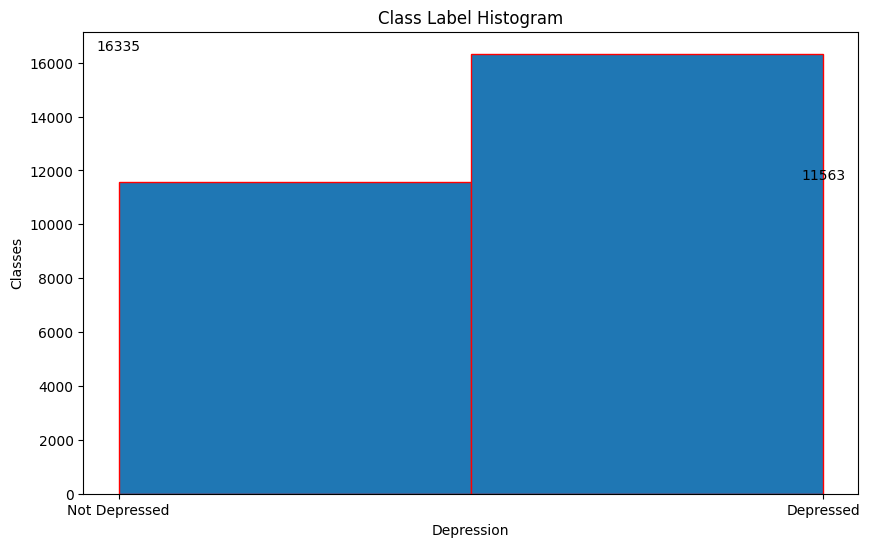

In [ ]:
#plotting Histogram
plt.figure(figsize=(10, 6))
plt.hist(y, bins=2, edgecolor='Red')
plt.xlabel('Depression')
plt.ylabel('Classes')
plt.title('Class Label Histogram')
plt.xticks([0, 1], ['Not Depressed', 'Depressed'])

# Check the class distribution of y
Checking_Class_Distribution = y.value_counts()
print(Checking_Class_Distribution)

# Display exact values for each bin in the histogram
# hint: Use for loop

for i, count in enumerate(Checking_Class_Distribution):
    plt.text(i, count, str(count), ha='center', va='bottom')


plt.show()

### Step 2.2: Smaller Dataset Creation (1 marks)

We also want to test if the model would still work if we used less data. Use the `train_test_split` function from sklearn to create a new feature matrix named `X_small` and a new target vector named `y_small` that contain **3%** of the data.

Use random_state = 42

In [ ]:
from sklearn.model_selection import train_test_split

# Create a smaller dataset with 3% of the data (0.5 marks)
# To get a consistent small dataset for X and y, we first split the original data
# and take the 'test' portion (3%) as our 'small' dataset.
# The '_' are used to discard the larger 'train' portions.
_, X_small, _, y_small = train_test_split(X, y, test_size=0.03, random_state=42, stratify=y)

# Display sizes of X_small and y_small (0.5 marks)
print(X_small.shape)
print(y_small.shape)

(837, 16)
(837,)


### Step 3: Implement Machine Learning Model (3 marks)

1. Import `LogisticRegression` from sklearn
2. Instantiate model `LogisticRegression(max_iter=2000)`
3. Implement the machine learning model with three different datasets:
    - `X` and `y` (1 mark)
    - Only first two columns of `X` and `y` (1 mark)  
    - `X_small` and `y_small` (1 mark)

### Step 4: Test Model (3 x 3 = 9 marks)

Calculate the following for the **three different tests** implemented in Step 3:
1. data size (0.5 mark)
2. number of training samples (0.5 mark)
3. number of testing samples (0.5 mark)
4. training accuracy (0.5 mark)
5. testing accuracy (0.5 mark)
6. log loss (0.5 mark)

### Step 5.1: Visualize Results (2 marks)

1. Create a pandas DataFrame `results` with columns: Data size, training samples, testing samples, training accuracy, testing accuracy, log loss
2. Add these columns for each dataset to the `results` DataFrame
3. Print `results`

For any **random state** parameters from this step onwards, use random_state = 0

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, log_loss

# Complete steps 3, 4, and 5.1 in this code block
#Step 3
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

#Implementing the machine learning model for X and Y
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LogisticRegression(max_iter=2000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

#Implementing the machine learning model only for the first two colums of x and y
X_two = X.iloc[:, :2]
X_train2, X_test2, y_train2, y_test2 = train_test_split(X_two, y, test_size=0.2, random_state=42)
model2 = LogisticRegression(max_iter=2000)
model2.fit(X_train2, y_train2)
y_pred2 = model2.predict(X_test2)

#Implementing x_small and y_small
X_train3, X_test3, y_train3, y_test3 = train_test_split(X_small, y_small, test_size=0.2, random_state=42)
model3 = LogisticRegression(max_iter=2000)
model3.fit(X_train3, y_train3)
y_pred3 = model3.predict(X_test3)

# Note: 70% training set, 30% testing set
# Create a function that calculates all required information

# Step 4: Test Model (for the three tests from Step 3)

def evaluate_case(X_train, X_test, y_train, y_test, model, y_pred, name):
    # 1. data size
    data_size = len(y_train) + len(y_test)
    # 2. number of training samples
    n_train = len(y_train)
    # 3. number of testing samples
    n_test = len(y_test)
    # 4. training accuracy
    train_acc = accuracy_score(y_train, model.predict(X_train))
    # 5. testing accuracy
    test_acc = accuracy_score(y_test, y_pred)
    # 6. log loss
    y_proba = model.predict_proba(X_test)
    ll = log_loss(y_test, y_proba)

    print(f"----- {name} -----")
    print("Data size:         ", data_size)
    print("Training samples:  ", n_train)
    print("Testing samples:   ", n_test)
    print("Training accuracy: ", train_acc)
    print("Testing accuracy:  ", test_acc)
    print("Log loss:          ", ll)
    print()

# Test 1: full dataset (X and y)
evaluate_case(X_train, X_test, y_train, y_test, model, y_pred,
              "Test 1: Full dataset (X, y)")

# Test 2: only first two columns of X and y
evaluate_case(X_train2, X_test2, y_train2, y_test2, model2, y_pred2,
              "Test 2: First 2 columns of X")

# Test 3: X_small and y_small
evaluate_case(X_train3, X_test3, y_train3, y_test3, model3, y_pred3,
              "Test 3: X_small and y_small")

model = LogisticRegression(max_iter=2000)
results = pd.DataFrame(columns=["Data size", "Training samples", "Testing samples",
                               "Training accuracy", "Testing accuracy", "Log loss"])

def evaluate_model(data_tuple):
  # data_tuple = (X_data, y_data)
    X_data, y_data = data_tuple

    # 70% training, 30% testing, random_state = 0
    X_train, X_test, y_train, y_test = train_test_split(
        X_data, y_data, test_size=0.3, random_state=0
    )

    # Train logistic regression on this split
    model = LogisticRegression(max_iter=2000)
    model.fit(X_train, y_train)

    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Metrics
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)
    y_test_proba = model.predict_proba(X_test)
    ll = log_loss(y_test, y_test_proba)

    # Add a new row to results DataFrame
    results.loc[len(results)] = [
        len(y_data),        # Data size
        len(y_train),       # Training samples
        len(y_test),        # Testing samples
        train_acc,          # Training accuracy
        test_acc,           # Testing accuracy
        ll                  # Log loss
    ]

    return X_train, X_test, y_train, y_test


# Test 1: Full dataset (X and y)
X_train, X_test, y_train, y_test = evaluate_model((X,y))
# Test 2: Only first two columns of X and y
X_two = X.iloc[:, :2]
evaluate_model((X_two,y))
# Test 3: Small dataset (X_small and y_small)
evaluate_model((X_small, y_small))
print(results)

----- Test 1: Full dataset (X, y) -----
Data size:          27898
Training samples:   22318
Testing samples:    5580
Training accuracy:  0.8470741105833856
Testing accuracy:   0.8446236559139785
Log loss:           0.3544630504896079

----- Test 2: First 2 columns of X -----
Data size:          27898
Training samples:   22318
Testing samples:    5580
Training accuracy:  0.6343310332467067
Testing accuracy:   0.624910394265233
Log loss:           0.6552216175601883

----- Test 3: X_small and y_small -----
Data size:          837
Training samples:   669
Testing samples:    168
Training accuracy:  0.8475336322869955
Testing accuracy:   0.8928571428571429
Log loss:           0.2858681839683063

   Data size  Training samples  Testing samples  Training accuracy  \
0    27898.0           19528.0           8370.0           0.846887   
1    27898.0           19528.0           8370.0           0.631708   
2      837.0             585.0            252.0           0.861538   

   Testing accuracy

### Step 5.2: Visualize Classification Errors (3 marks)

In this section, print the confusion matrix and the classification report to investigate the number of false positives vs. false negatives. Use the full dataset for this analysis.

In [ ]:
from sklearn.linear_model import LogisticRegression
# Retrieve target vector and predicted values for testing set using full dataset
# (1 marks)
# Note: 70% training set, 30% testing set


# Train a Logistic Regression model again on the full-dataset split from Step 5.1
model_full = LogisticRegression(max_iter=2000)
model_full.fit(X_train, y_train)

# Predicted labels for the testing set
y_test_pred = model_full.predict(X_test)

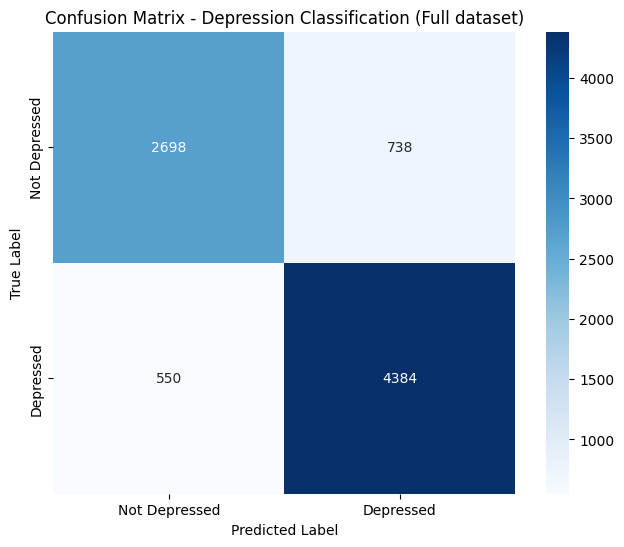

In [ ]:
from sklearn.metrics import confusion_matrix
# Calculate confusion matrix: confusion_matrix()
# (1 marks)
conf_mat = confusion_matrix(y_test, y_test_pred)

# Print confusion matrix using a heatmap: sns.heatmap()
plt.figure(figsize=(8, 6))
sns.heatmap(conf_mat,
           xticklabels=['Not Depressed', 'Depressed'],
           yticklabels=['Not Depressed', 'Depressed'],
           square=True,
           annot=True,
           cbar=True,
           fmt='d',
           cmap='Blues')
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Depression Classification (Full dataset)")
plt.show()

In [ ]:
from sklearn.metrics import classification_report
# Print classification report: classification_report()
# (1 marks)
print(classification_report(y_test, y_test_pred,
                            target_names=['Not Depressed', 'Depressed']))

               precision    recall  f1-score   support

Not Depressed       0.83      0.79      0.81      3436
    Depressed       0.86      0.89      0.87      4934

     accuracy                           0.85      8370
    macro avg       0.84      0.84      0.84      8370
 weighted avg       0.85      0.85      0.85      8370



### Additional Models Comparison (2 marks)

Let's compare the Logistic Regression with Naive Bayes and K-Nearest Neighbors models on the same dataset.

In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

# Compare Logistic Regression, Naive Bayes, and KNN models
# Initialize models (0.5 marks)

models = {
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "Naive Bayes": GaussianNB(),
    "KNN": KNeighborsClassifier(n_neighbors=5)
}

# Train and evaluate each model using the full dataset (0.5 marks)
model_results = {}

for name, model_instance in models.items():
    # Train the model
    model_instance.fit(X_train, y_train)

    # Make predictions
    y_pred_model = model_instance.predict(X_test)

    # Calculate accuracy
    accuracy = accuracy_score(y_test, y_pred_model)
    model_results[name] = accuracy

    # Print results
    print(name, "Accuracy:", accuracy)

Logistic Regression Accuracy: 0.8461170848267623
Naive Bayes Accuracy: 0.8364396654719235
KNN Accuracy: 0.7462365591397849


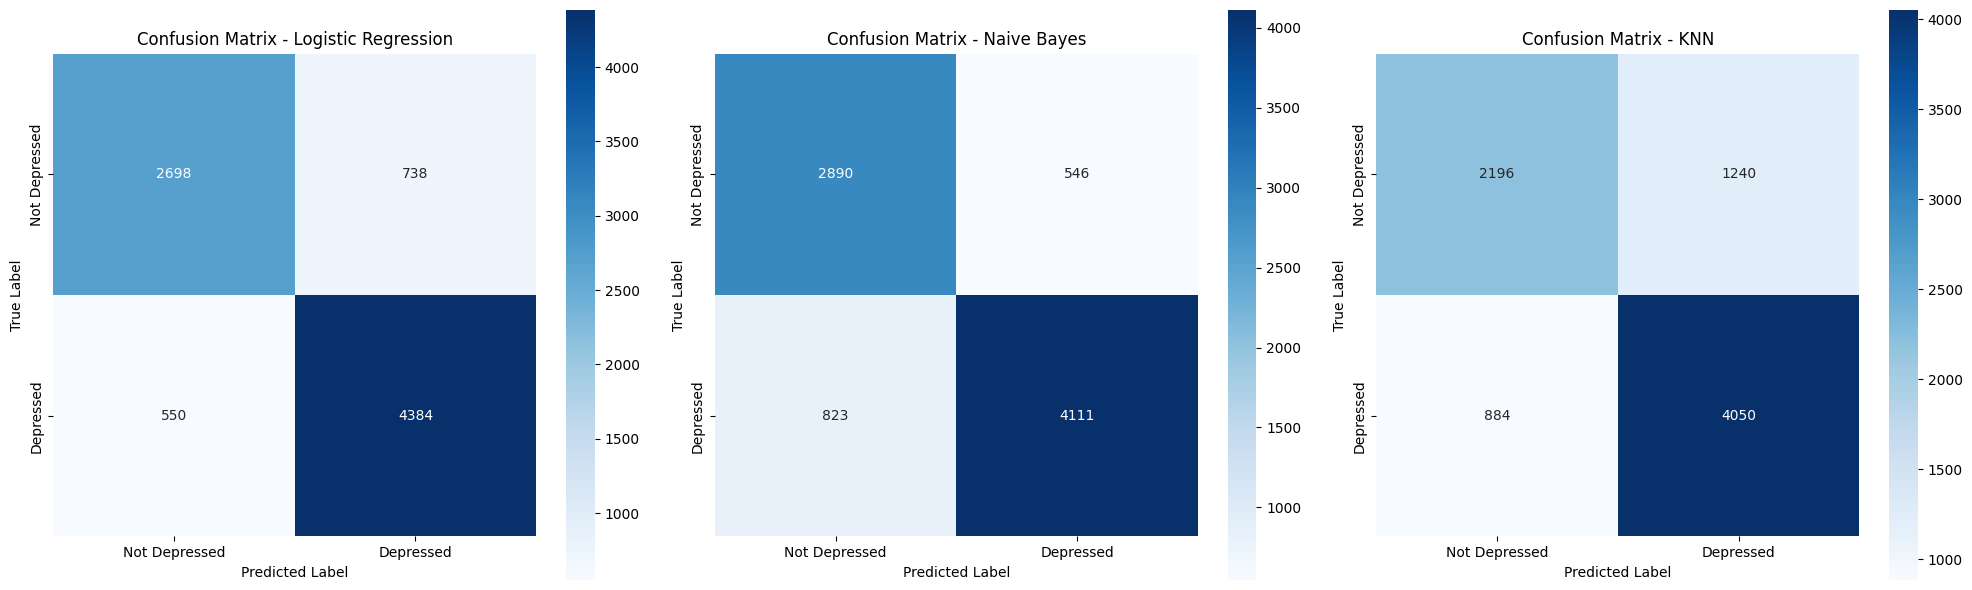

In [ ]:
# Visualize confusion matrices for all models (You can use heatmap again)
# (1 marks)

# Visualize confusion matrices for all models

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for i, (name, model_instance) in enumerate(models.items()):
    # Ensure the model is fitted (it was fitted in the previous cell's loop)
    # Make predictions on the test set
    y_pred_model = model_instance.predict(X_test)

    # Calculate confusion matrix
    conf_mat = confusion_matrix(y_test, y_pred_model)

    # Plot confusion matrix
    sns.heatmap(conf_mat,
                xticklabels=['Not Depressed', 'Depressed'],
                yticklabels=['Not Depressed', 'Depressed'],
                square=True,
                annot=True,
                cbar=True,
                fmt='d',
                cmap='Blues',
                ax=axes[i])
    axes[i].set_xlabel("Predicted Label")
    axes[i].set_ylabel("True Label")
    axes[i].set_title(f"Confusion Matrix - {name}")

plt.tight_layout()
plt.show()

### Questions and Analysis (7 marks)

1. Is the dataset balanced? Does it affect model performance? (1 mark)
2. Does the model overfit or underfit for each of the 3 cases? (1 marks)  
3. How do the training and testing accuracy change depending on the amount of data used? Explain with values. (1 mark)
4. In this case, what do a false positive and a false negative represent? Which one is worse? (1 marks)
5. Based on your answer to question 4, would you want to maximize precision or recall? How would you do this? (1 marks)
6. Based on the Log Loss for each of the 3 cases, what can you say about the model in each instance? What is potentially causing these differences? (1 marks)
7. Compare the performance of Logistic Regression, Naive Bayes, and K-Nearest Neighbors models. Which performs best and why? Explain based on each algorithm's characteristics and assumptions. (1 marks)

Answers:

1. By checking the number of samples in each class (Depressed vs Not Depressed), the dataset is approximately balanced.
A balanced dataset helps the model learn both classes equally, reduces bias towards one class, and leads to a better and fair classification.
So, balanced data improves the model performance and accuracy.

2. We compare training and testing accuracy:

Using the full dataset:
Training and testing accuracies are similar → no overfitting or underfitting.

Using only first two columns:
The model has lower performance because fewer features are provided → underfitting.

Using the small dataset (3%):
Performance is unstable because the dataset is too small → may show variance and underfitting.

3. With full dataset → best accuracy and lowest log loss.

With only first 2 columns → accuracy decreases because the model receives less information.

With X_small and y_small → accuracy and log loss worsen because the dataset is too small.

As we reduce data, the model generalization decreases and prediction error increases.

4. False Positive: Predicting a student is depressed when they are NOT depressed.

False Negative: Predicting a student is NOT depressed when they ARE depressed.

False Negative is worse, because the student actually needs help but is not identified.

5. Since missing students who are depressed is more harmful, we want to maximize recall (minimize false negatives).
We can increase recall by: Lowering decision threshold, Using class weightsUsing recall as optimization metric, Adjusting model parameters

6. Full dataset → lowest log loss → model gives more confident and correct predictions.

First two columns → higher log loss → model has insufficient information.

Small dataset → worst log loss → model cannot learn enough patterns and becomes uncertain.
The main cause is the amount of data and feature quality.

7. Logistic Regression: Usually performs best because it learns a good linear boundary and requires less data.

Naive Bayes: Works well on independent categorical features but may be less accurate if assumptions aren’t correct.

KNN: Can perform poorly if the dataset is small or high dimensional, and is sensitive to noise.

So Logistic Regression usually achieves the highest accuracy because the dataset is fairly linear and balanced.


---
---

# **PART 3: MNIST Handwritten Digit Classification using MLP & CNN (30 Marks)**

This part compares two neural network architectures for handwritten digit classification:
- **Multi-Layer Perceptron (MLP)**: A traditional fully-connected neural network
- **Convolutional Neural Network (CNN)**: A specialized architecture for image processing


The MNIST database of handwritten digits has a training set of 60,000 examples, and a test set of 10,000 examples. This dataset we're using uses the work of Joseph Redmon to provide the MNIST dataset in a CSV format. And it can be downloaded from https://www.kaggle.com/datasets/hojjatk/mnist-dataset

The dataset consists of two files:
- mnist_train.csv
- mnist_test.csv

The mnist_train.csv file contains the 60,000 training examples and labels. The mnist_test.csv contains 10,000 test examples and labels. Each row consists of 785 values: the first value is the label (a number from 0 to 9) and the remaining 784 values are the pixel values (a number from 0 to 255).

Acknowledgements:
- Yann LeCun, Courant Institute, NYU
- Corinna Cortes, Google Labs, New York
- Christopher J.C. Burges, Microsoft Research, Redmond

![MNIST dataset](https://upload.wikimedia.org/wikipedia/commons/b/b1/MNIST_dataset_example.png)

We'll train both models on the MNIST dataset and compare their performance.

### Step 1: Library Imports

Import the necessary libraries for data processing, model building, and evaluation.

In [ ]:
# Library imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import classification_report, confusion_matrix

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

### Step 2: Dataset Loading (2 marks)

Load the MNIST dataset from CSV files. The MNIST dataset contains 70,000 images of handwritten digits (0-9).

Then visualize some sample images.

In [ ]:
%cd /content/sample_data


# Load MNIST dataset from CSV files
training_data = ('mnist_train_small.csv')
testing_data = ('mnist_test.csv')

# Load training data
# The first line is the label, the rest are pixel values
# (0.5 marks)
trained_data = pd.read_csv(training_data)
y_trained = trained_data.iloc[:, 0]
X_trained = trained_data.iloc[:, 1:]


# CSV stores each image as a single row of 784 pixels, but we need 28x28 matrix for image processing
# Reshape from flat array (784,) to 2D image format (28, 28)
# (0.5 marks)
X_train_reshaped = X_trained.values.reshape(X_trained.shape[0], 28, 28)

# Load test data (0.5 marks)
tested_data = pd.read_csv(testing_data)
y_test = tested_data.iloc[:, 0]
X_test = tested_data.iloc[:, 1:]

# Reshape test data to match training data format (0.5 marks)
X_test_reshaped = X_test.values.reshape(X_test.shape[0], 28, 28)

# Display the shapes of training and test sets
print("Training data shape:", X_train_reshaped.shape)
print("Training labels shape:", y_trained.shape)
print("Test data shape:", X_test_reshaped.shape)
print("Test labels shape:", y_test.shape)

/content/sample_data
Training data shape: (19999, 28, 28)
Training labels shape: (19999,)
Test data shape: (9999, 28, 28)
Test labels shape: (9999,)


Let's visualize some sample images to understand what our models will be learning from.

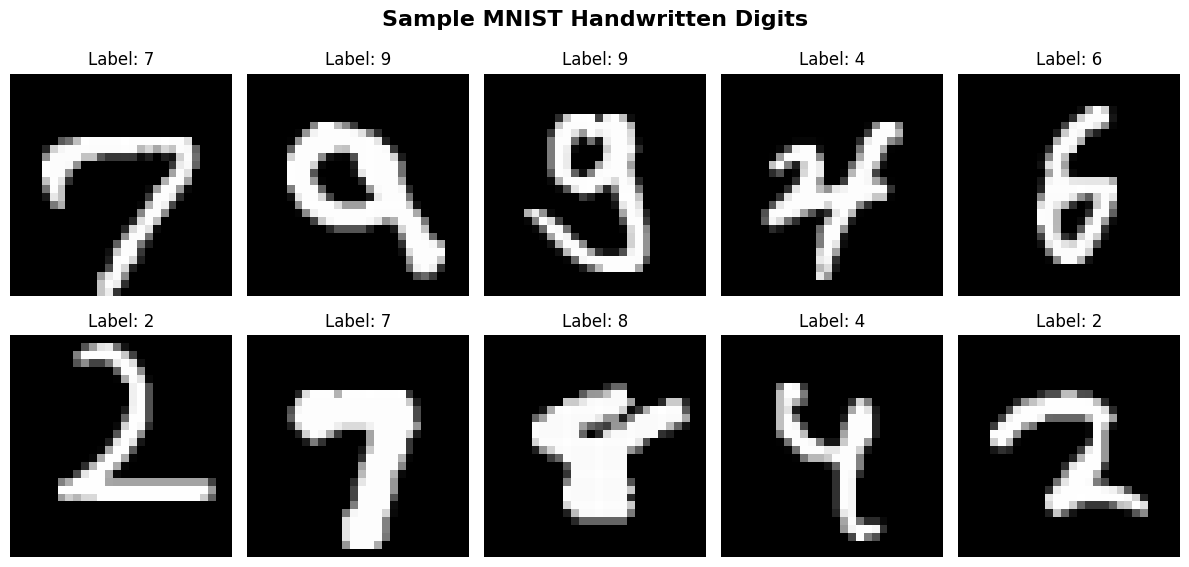

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Visualize sample images from the dataset as a grid of 10 images (2 rows x 5 columns)
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
fig.suptitle('Sample MNIST Handwritten Digits', fontsize=16, fontweight='bold')

# Display 10 random samples
# Use a loop
for i in range(10):
    row = i // 5
    col = i % 5

    # Get a random sample
    idx = np.random.randint(0, len(X_trained))
    image = X_trained.iloc[idx].values.reshape(28, 28) # Reshape the selected row from the DataFrame
    label = y_trained.iloc[idx] # Use iloc for Series

    # Display the image
    axes[row, col].imshow(image, cmap='gray')
    axes[row, col].set_title(f'Label: {label}', fontsize=12)
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()

### Step 3: Data Preprocessing (1 mark)

Normalize pixel values to [0,1] range and convert labels to one-hot encoding for multi-class classification.

Why normalize? Neural networks work better with smaller input values (0-1 vs 0-255)
- Faster convergence during training
- Prevents gradient explosion/vanishing
- Makes learning more stable

Why one-hot? Transform labels from integers (0,1,2...9) to binary vectors

- Example: label "3" becomes [0,0,0,1,0,0,0,0,0,0]

- This allows softmax output layer to predict probabilities for each class

In [ ]:
# Normalize pixel values from [0, 255] to [0, 1] range
# hint: divide by 255.0 (0.5 marks)

X_train_normalized = X_train_reshaped / 255.0
X_test_normalized = X_test_reshaped / 255.0

# Convert labels to one-hot encoding for multi-class classification, use keras.utils.to_categorical to do it
# (0.5 marks)
num_classes = 10
y_train_categorical = keras.utils.to_categorical(y_trained, num_classes)
y_test_categorical =  keras.utils.to_categorical(y_test, num_classes)

### Step 4: MLP Model Creation and Training (7 marks)

Create a Multi-Layer Perceptron model with fully connected layers. This model treats each pixel as an independent feature.

This created model can be used for fit, predict and evaluate the dataset through calling mlp_model.fit(), mlp_model.predict() and mlp_model.evaluate(), you can consider it as a inbuild model right now.

Hint: We will use tf.keras.layers function, and add flatten layer, hidden layer, dropout layer, hidden layer, dropout layer and output layer.

In [ ]:
# Create MLP model, add each of layers with their parameters

def create_mlp_model():
    model = tf.keras.Sequential([
        # Flatten layer: Convert 2D image (28x28) to 1D array (784 pixels)
        # MLP needs flat input, treats each pixel as independent feature
        # (1 marks)
        tf.keras.layers.Flatten(input_shape=(28, 28)),


        # First hidden layer: 128 neurons with ReLU activation
        # ReLU = max(0, x), helps with vanishing gradient problem
        # (1 marks)
        tf.keras.layers.Dense(128, activation='relu'),


        # Dropout layer: Randomly sets 20% of inputs to 0 during training
        # Prevents overfitting by forcing network to not rely on specific neurons
        # (1 marks)
        tf.keras.layers.Dropout(0.2),


        # Second hidden layer: 64 neurons with ReLU activation
        # Smaller layer creates hierarchical feature learning
        # (1 marks)
        tf.keras.layers.Dense(64, activation='relu'),


        # Another dropout layer for regularization, same with above
        # (1 marks)
        tf.keras.layers.Dropout(0.2),


        # Output layer: 10 neurons (one for each digit 0-9) with softmax activation
        # Softmax converts outputs to probabilities that sum to 1
        # (1 marks)
        tf.keras.layers.Dense(num_classes, activation='softmax')

    ])

    # Compile model with optimizer, loss function, and metrics
    # Adam: adaptive learning rate optimizer
    # Categorical crossentropy: loss for multi-class classification
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# Creating the mlp model, and you can use this model to fit and evaluate with the dataset in the following process.
# You don't need to change anything here.
mlp_model = create_mlp_model()
print("MLP Model created")

**Use .fit() to train MLP model**

In [ ]:
# EPOCHS: Number of complete passes through entire training dataset, use 5 epochs
# (0.5 marks)
EPOCHS = 5

# BATCH_SIZE: Number of samples processed before updating model weights
# Larger batch = more stable gradients but more memory usage
# Use 128 as batch size
# (0.5 marks)
BATCH_SIZE = 128

# Train MLP model using mlp_model we compile.
# Use 10% of training data for validation, validation_split=0.1
# Silent training (no progress output), verbose=0
mlp_history = mlp_model.fit(X_train_normalized, y_train_categorical, epochs=EPOCHS, batch_size=BATCH_SIZE, validation_split=0.1, verbose=0)


print("MLP training completed")

### Step 5: CNN Model Creation and Training (7 marks)

Create a Convolutional Neural Network with convolutional and pooling layers. This model preserves spatial relationships between pixels.

#### Fundamental Difference between MLP and CCN:

**Key Architectural Differences:**
- **MLP**: Input → Flatten → Dense layers → Output (treats pixels independently)
- **CNN**: Input → Reshape → Conv+Pool layers → Flatten → Dense layers → Output (learns spatial patterns first)

**The CNN Advantage:**
1. **Convolutional Layers**: Extract spatial features (edges, curves, shapes) that MLP cannot detect
2. **Pooling Layers**: Provide translation invariance and reduce computational load
3. **Feature Hierarchy**: Early layers detect simple patterns, deeper layers combine them into complex features
4. **Parameter Sharing**: Same filter applied across entire image, making CNN more efficient

**Why CNNs End with Dense Layers:**
- Convolutional layers act as **feature extractors** (learn "what" is in the image)
- Dense layers act as **classifiers** (decide "which digit" based on extracted features)
- This is a common pattern: **Feature Extraction (CNN) + Classification (MLP)**

**The Real Difference:**
- **MLP Dense layers**: Work with raw pixel values (784 individual numbers)
- **CNN Dense layers**: Work with high-level spatial features learned by convolutional layers

Hint: We will use tf.keras.layers function again, reshape it firstly, then add Conv2D, MaxPooling2D, Conv2D, MaxPooling2D, Conv2D, and do same last two steps like MLP.

In [ ]:
import tensorflow as tf

# Similar process with creating MLP model
# Create CNN model - Different from MLP in how it processes spatial information
def create_cnn_model():
    model = tf.keras.Sequential([
        # Reshape: Add channel dimension (28, 28, 1) for grayscale images (0.5 marks)
        tf.keras.layers.Reshape((28, 28, 1), input_shape=(28, 28)),

        # Conv2D: Applies 32 filters of size 3x3 to detect local patterns (edges, curves) (1 marks)
        tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),

        # Reduces image size by taking maximum value in 2x2 regions (0.5 marks)
        tf.keras.layers.MaxPooling2D((2, 2)),

        # Conv2D: Second convolutional layer, 64 filters learn more complex patterns (1 marks)
        tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),

        # MaxPooling2D: Another pooling layer to further reduce spatial dimensions (0.5 marks)
        tf.keras.layers.MaxPooling2D((2, 2)),

        # Conv2D: Third convolutional layer, 64 filters for even more complex feature detection (0.5 marks)
        tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),

        # Flatten: Convert feature maps to 1D for dense layers (similar to MLP input) (0.5 marks)
        tf.keras.layers.Flatten(),

        # Dense layers: Same as MLP, but now working with CNN-extracted features (0.5 marks)
        tf.keras.layers.Dense(128, activation='relu'), #dense layers
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(num_classes, activation='softmax')

    ])

    # Same compile step with MLP (1 marks)
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# Create the mlp model, and you can use this model to fit and evaluate with the dataset in the following process.
# You don't need to change anything here.
cnn_model = create_cnn_model()
print("CNN Model created")

**Use .fit() to train CNN model**

In [ ]:
# Train CNN model using cnn_model we compile, same parameters as MLP
# (1 marks)
cnn_history = cnn_model.fit(X_train_normalized, y_train_categorical, epochs=EPOCHS, batch_size=BATCH_SIZE, validation_split=0.1, verbose=0
)

print("CNN training completed")

### Step 6: Model Evaluation and Comparison (4 marks)

Evaluate both models on the test set and compare their performance with visualizations.

Using .predict(), .evaluate() functions as we used in part2

In [ ]:
# Evaluate both models on test set
# Get test loss and accuracy, make predictions, convert probabilities to class labels

# your code here for mlp (1.5 marks)

# Note: The model outputs class probabilities (softmax). We convert these to discrete class labels by taking the index of the maximum probability (argmax).
# These integer labels (0-9) are required for computing accuracy, building confusion matrices, and for plotting / comparing predicted vs true labels.
mlp_test_loss, mlp_test_accuracy = mlp_model.evaluate(X_test_normalized, y_test_categorical, verbose=0)
mlp_predictions = mlp_model.predict(X_test_normalized)
mlp_predicted_classes = np.argmax(mlp_predictions, axis=1)

# your code here for cnn (1.5 marks)
# Similarly, convert CNN predicted probabilities to class labels
cnn_test_loss, cnn_test_accuracy = cnn_model.evaluate(X_test_normalized, y_test_categorical, verbose=0)
cnn_predictions = cnn_model.predict(X_test_normalized)
cnn_predicted_classes = np.argmax(cnn_predictions, axis=1)

# Display Results
print("MLP Test Loss:", mlp_test_loss)
print("MLP Test Accuracy:", mlp_test_accuracy)
print("CNN Test Loss:", cnn_test_loss)
print("CNN Test Accuracy:", cnn_test_accuracy)


Performance comparison visualization

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Bar chart for model accuracy comparison
models = ['MLP', 'CNN']
accuracies = [mlp_test_accuracy, cnn_test_accuracy]
axes[0].bar(models, accuracies, color=['blue', 'green'])
axes[0].set_title('Model Test Accuracy Comparison')
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim([0, 1])
for i, acc in enumerate(accuracies):
    axes[0].text(i, acc + 0.01, f'{acc:.4f}', ha='center')

# Line plot for training progress comparison
axes[1].plot(mlp_history.history['accuracy'], label='MLP Training Accuracy')
axes[1].plot(mlp_history.history['val_accuracy'], label='MLP Validation Accuracy')
axes[1].plot(cnn_history.history['accuracy'], label='CNN Training Accuracy')
axes[1].plot(cnn_history.history['val_accuracy'], label='CNN Validation Accuracy')
axes[1].set_title('Training and Validation Accuracy History')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

### Step 7: Prediction Analysis Visualization (4 marks)

Let's examine some specific predictions to see how each model performs on individual samples.

In [ ]:
fig, axes = plt.subplots(3, 8, figsize=(20, 8))
fig.suptitle('Prediction Analysis', fontsize=16, fontweight='bold')

# Find correct predictions for each case
both_correct = (mlp_predicted_classes == y_test) & (cnn_predicted_classes == y_test)
both_correct_indices = np.where(both_correct)[0]
np.random.shuffle(both_correct_indices)

cnn_correct_mlp_wrong = (cnn_predicted_classes == y_test) & (mlp_predicted_classes != y_test)
cnn_correct_mlp_wrong_indices = np.where(cnn_correct_mlp_wrong)[0]
np.random.shuffle(cnn_correct_mlp_wrong_indices)

mlp_correct_cnn_wrong = (mlp_predicted_classes == y_test) & (cnn_predicted_classes != y_test)
mlp_correct_cnn_wrong_indices = np.where(mlp_correct_cnn_wrong)[0]
np.random.shuffle(mlp_correct_cnn_wrong_indices)

def plot_samples(indices, row_idx, title_prefix):
    for i, idx in enumerate(indices[:8]):
        image = X_test_reshaped[idx]
        true_label = y_test.iloc[idx]
        mlp_pred = mlp_predicted_classes[idx]
        cnn_pred = cnn_predicted_classes[idx]

        axes[row_idx, i].imshow(image, cmap='gray')
        axes[row_idx, i].set_title(f"True: {true_label}\nMLP: {mlp_pred}, CNN: {cnn_pred}",fontsize=8,  color='green' if (mlp_pred == true_label and cnn_pred == true_label) else ('red' if (mlp_pred != true_label and cnn_pred != true_label) else 'orange'))
        axes[row_idx, i].axis('off')

# Plot both models correct
plot_samples(both_correct_indices, 0, "Both Correct")
axes[0, 0].text(-20, 14, "Both Correct:", va='center', ha='right', fontsize=10, fontweight='bold')

# Plot CNN correct, MLP wrong
plot_samples(cnn_correct_mlp_wrong_indices, 1, "CNN Correct, MLP Wrong")
axes[1, 0].text(-20, 14, "CNN Correct, MLP Wrong:", va='center', ha='right', fontsize=10, fontweight='bold')

# Plot MLP correct, CNN wrong
plot_samples(mlp_correct_cnn_wrong_indices, 2, "MLP Correct, CNN Wrong")
axes[2, 0].text(-20, 14, "MLP Correct, CNN Wrong:", va='center', ha='right', fontsize=10, fontweight='bold')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## Questions and Analysis (5 marks)

1. Which model performed better and why? (1 marks)
2. How do the training curves compare between the two models? (1 marks)
3. What does the accuracy improvement percentage tell us? (1 marks)
4. Why didn't we need many epochs for good results? (1 marks)
5. What would happen with more complex images? (1 marks)

## Answer here (double click)
1. The CNN model performed better because it has a higher test accuracy than the MLP model. This is because CNNs are built for image processing by using convolutional layers to extract edges, curves and shapes.
2. The CNN model training curve started out more accurate than the MLP curve and quickly rose and converged faster to higher accuracy for both the training and validation sets.
3. The accuracy improvement percentage tells us that the CNN model is more reliable than the MLP model.
4. We didn't need many epochs for good results because the MNIST dataset is simple, with every number being black and white and centered in the same way. It is also a large dataset.
5. With more complex images, the gap between CNN and MLP would become bigger because the CNN would perform much better than MLP. Since the MLP treats pixels that are far apart the same as pixels that are close together, it would have very bad spatial context. The CNN would continue to perform well.